To prepare the data run:
make paper_fig_4b

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 2} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 7.5
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.4
_MARKERS = ["o", "^", "v", "<", ">", "s", "d"]

_SNS_PARAMS = {"markers":_MARKERS, "dashes":True, "markersize": 16}

In [2]:
from glob import glob
from os.path import join

densities = ["0.0", "0.0001", "0.001", "0.003", "0.005", "0.008", "0.01"]
# tot_dataframe = pd.concat(map(pd.read_csv, glob(join('../../..', "bench_results_seg_scan_sc_128_*.csv"))))
tot_dataframe = pd.concat(map(pd.read_csv, [join('./', f"bench_results_seg_scan_sc_128_{dens}_fp16.csv") for dens in densities]))
tot_dataframe["operator"] = "SegScanSingleCore"

input_size = tot_dataframe['size'] * 2 + tot_dataframe['size'] # As I need to take as input a vector of SIZE elements of half, and a vector of INT8, hence size * 3
output_size = tot_dataframe['size'] * 4 # The output is in float, hence SIZE elements of 32 bits
tot_dataframe['mem_bytes'] = (tot_dataframe['size'] * (2 + 1))  + tot_dataframe['size'] * 4

tot_dataframe['bandwidth_mbps'] = (tot_dataframe['mem_bytes']) / (tot_dataframe['time_us']) #MB/s
tot_dataframe['bandwidth_gbps'] = tot_dataframe["bandwidth_mbps"] / 1000
tot_dataframe["density"] = ["%s" % x for x in tot_dataframe["density"]]


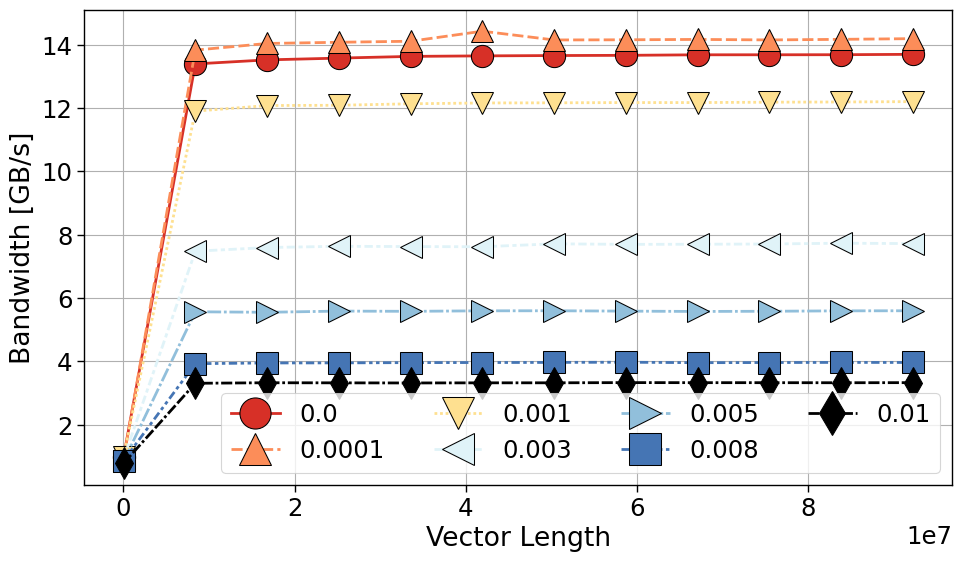

In [8]:

df = tot_dataframe[tot_dataframe["size"] < 10 * 1e7]

# Color palette
#d73027
#fc8d59
#fee090
#e0f3f8
#91bfdb
#4575b4
color_palette = ["#d73027",
"#fc8d59",
"#fee090",
"#e0f3f8",
"#91bfdb",
"#4575b4",
"black"]

plt.figure(figsize=(10, 6))
sns.lineplot(x='size', y='bandwidth_gbps', hue='density', style='density', data=df, palette=color_palette,markeredgecolor='black', **_SNS_PARAMS)

plt.xlabel('Vector Length')
plt.ylabel('Bandwidth [GB/s]')
# plt.title('Segmented Scan (Single AI Core | S=128)')
plt.legend(loc="lower right", markerscale=_LEGEND_MARKER_SCALE, ncol=4)
plt.tight_layout()

plt.grid(True)
plt.savefig("segm_scan_sc_s_128.png")
plt.savefig("segm_scan_sc_s_128.pdf")
plt.show()
